# Workshop 3: Data Preparation Pipeline

Notebook นี้ออกแบบสำหรับ Session 02 (Stat on Campus) เพื่อฝึกกระบวนการเตรียมข้อมูลก่อนทำ EDA

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toche7/SlideAIDATADGA/blob/main/slides/workshop-03-data-preparation-pipeline.ipynb)

## Learning Objectives
- ดึงข้อมูล Titanic มาเป็น DataFrame
- ตรวจสอบคุณภาพข้อมูล (missing, duplicate, type, outlier)
- ทำ data cleaning และจัดข้อมูลให้อยู่ในรูปแบบที่พร้อมวิเคราะห์
- สรุปผลการเตรียมข้อมูลเป็น checklist เพื่อใช้ต่อใน EDA

In [5]:
# 1) Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [6]:
# 2) Load Titanic dataset (with fallback URL)
fallback_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

try:
    df = sns.load_dataset('titanic')
    data_source = 'seaborn.titanic'
except Exception:
    df = pd.read_csv(fallback_url)
    data_source = 'Fallback CSV'

print(f'Loaded from: {data_source}')
print(f'Shape: {df.shape}')
df.head()

Loaded from: seaborn.titanic
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
# 3) Quick profile
print('Columns:', list(df.columns))
display(df.info())
display(df.describe(include='all').T.head(10))

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: b

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# 4) Data quality check: missing values + duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
quality_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

print('Top missing columns')
display(quality_table.head(15))

dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

Top missing columns


,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22
sex,0,0.00
pclass,0,0.00
survived,0,0.00
fare,0,0.00
parch,0,0.00
sibsp,0,0.00


Duplicate rows: 107


In [9]:
# 5) Type conversion and standardization
# Convert numeric-like columns
for col in ['age', 'fare', 'sibsp', 'parch', 'pclass']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize text columns
text_cols = [c for c in ['sex', 'embarked', 'embark_town', 'class', 'who', 'deck', 'alive'] if c in df.columns]
for c in text_cols:
    df[c] = df[c].astype('string').str.strip()

preview_cols = [c for c in ['survived', 'pclass', 'sex', 'age', 'fare', 'embarked'] if c in df.columns]
df[preview_cols].head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [10]:
# 6) Handle missing and duplicates for analysis-ready table
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Fill missing values with practical rules
if {'age', 'sex', 'pclass'}.issubset(df_clean.columns):
    df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(lambda s: s.fillna(s.median()))

if 'embarked' in df_clean.columns:
    embarked_mode = df_clean['embarked'].mode(dropna=True)
    if not embarked_mode.empty:
        df_clean['embarked'] = df_clean['embarked'].fillna(embarked_mode.iloc[0])

if 'fare' in df_clean.columns:
    df_clean['fare'] = df_clean['fare'].fillna(df_clean['fare'].median())

# Drop columns that are mostly missing or IDs not needed for modeling
drop_cols = [c for c in ['deck', 'embark_town', 'alive', 'class', 'who'] if c in df_clean.columns]
df_clean = df_clean.drop(columns=drop_cols)

print('Original shape:', df.shape)
print('Cleaned shape :', df_clean.shape)
print('Remaining missing values:', int(df_clean.isna().sum().sum()))

Original shape: (891, 15)
Cleaned shape : (784, 10)
Remaining missing values: 0


In [11]:
# 7) Outlier inspection on fare using IQR
q1 = df_clean['fare'].quantile(0.25)
q3 = df_clean['fare'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df_clean[(df_clean['fare'] < lower) | (df_clean['fare'] > upper)]
print(f'Outlier rows (IQR rule): {len(outliers):,}')
display(outliers[['survived', 'pclass', 'sex', 'age', 'fare']].head())

Outlier rows (IQR rule): 102


,survived,pclass,sex,age,fare
27,0,1,male,19.0,263.0000
31,1,1,female,35.0,146.5208
34,0,1,male,28.0,82.1708
52,1,1,female,49.0,76.7292
61,1,1,female,38.0,80.0000


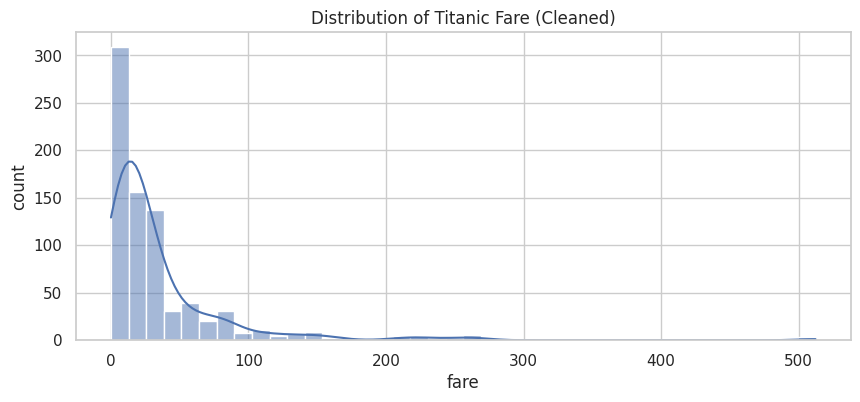

In [12]:
# 8) Quick visualization for quality check
plt.figure(figsize=(10, 4))
sns.histplot(df_clean['fare'], bins=40, kde=True)
plt.title('Distribution of Titanic Fare (Cleaned)')
plt.xlabel('fare')
plt.ylabel('count')
plt.show()

In [13]:
# 9) Build tidy summary dataset
group_cols = [c for c in ['pclass', 'sex'] if c in df_clean.columns]
tidy_df = (
    df_clean
    .groupby(group_cols, dropna=False, as_index=False)['survived']
    .mean()
    .rename(columns={'survived': 'survival_rate'})
)

print('Tidy shape:', tidy_df.shape)
tidy_df.head()

Tidy shape: (6, 3)


,pclass,sex,survival_rate
0,1,female,0.967742
1,1,male,0.371901
2,2,female,0.917808
3,2,male,0.184783
4,3,female,0.472441


In [14]:
# 10) Export cleaned outputs
df_clean.to_csv('workshop3_titanic_clean.csv', index=False)
tidy_df.to_csv('workshop3_titanic_tidy.csv', index=False)
print('Saved: workshop3_titanic_clean.csv')
print('Saved: workshop3_titanic_tidy.csv')

Saved: workshop3_titanic_clean.csv
Saved: workshop3_titanic_tidy.csv


## Reflection Questions
1. หลัง cleaning แล้ว จำนวนข้อมูลลดลงเท่าไร และเพราะอะไร?
2. คอลัมน์ไหนใน Titanic มี missing สูงที่สุด และควรจัดการแบบใด?
3. Outlier ของค่า fare ควรเก็บไว้หรือเอาออก เพราะอะไร?
4. หากจะทำ EDA ต่อ ควรตั้งคำถามอะไรเกี่ยวกับ survival rate?